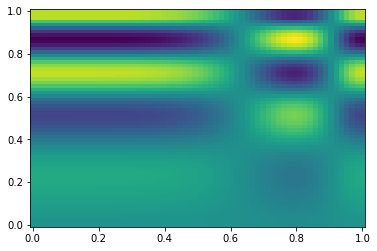

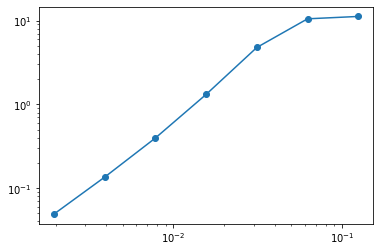

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def exact_soln(X,Y):
    gradX_phi = 8*np.pi * X*np.cos(4*np.pi*X**2)*np.cos(-2*np.pi*Y**3)
    gradY_phi = 6*np.pi * Y**2*np.sin(4*np.pi*X**2)*np.sin(-2*np.pi*Y**3)
    return gradX_phi, gradY_phi

def phi_function(X,Y):
    phi = np.sin(4*np.pi*X**2)*np.cos(2*np.pi*Y**3)
    return phi

def L_sq_norm(fXp, fYp, fX, fY, N):
    h = 1/N
    errX_sq = (fXp - fX)**2
    errY_sq = (fYp - fY)**2
    return np.sqrt( h**2 * np.sum(errX_sq + errY_sq) )

def central_diff_dirichlet(x,y,f):
    N = int(len(x))
    h = x.max()/N
    
    # Compute ghost cells for zero-gradient boundaries
    f_u = f[:,3] - 8*f[:,2] + 8*f[:,0]
    f_uu = f[:,2] - 8*f[:,1] + 8*f_u
    f_d = 8*f[:,N-1] - 8*f[:,N-3] + f[:,N-4]
    f_dd = 8*f_d - 8*f[:,N-2] + f[:,N-3]
    
    f_l = f[3,:] - 8*f[2,:] + 8*f[0,:]
    f_ll = f[2,:] - 8*f[1,:] + 8*f_l
    f_r = 8*f[N-1,:] - 8*f[N-3,:] + f[N-4,:]
    f_rr = 8*f_r - 8*f[N-2,:] + f[N-3,:]
    
    # Reshape ghost cell arrays
    f_u = np.reshape(f_u, (N,1))
    f_uu = np.reshape(f_uu, (N,1))
    f_d = np.reshape(f_d, (N,1))
    f_dd = np.reshape(f_dd, (N,1))
    
    f_l = np.reshape(f_l, (1,N))
    f_ll = np.reshape(f_ll, (1,N))
    f_r = np.reshape(f_r, (1,N))
    f_rr = np.reshape(f_rr, (1,N))
    
    # Precompute shifted arrays
    f_im2 = np.concatenate( (f_uu, f_u, f[:,:-2]),1 )
    f_im1 = np.concatenate( (f_u, f[:,:-1]),1 )
    f_ip1 = np.concatenate( (f[:,1:], f_d),1 )
    f_ip2 = np.concatenate( (f[:,2:], f_d, f_dd),1 )
    
    f_jm2 = np.concatenate( (f_ll, f_l, f[:-2,:]),0 )
    f_jm1 = np.concatenate( (f_l, f[:-1,:]),0 )
    f_jp1 = np.concatenate( (f[1:,:], f_r),0 )
    f_jp2 = np.concatenate( (f[2:,:], f_r, f_rr),0 )
    
    # Compute gradient: 4th order central finite diff
    gradX = (-1*f_jp2 + 8*f_jp1 - 8*f_jm1 + f_jm2) / (12*h)
    gradY = (-1*f_ip2 + 8*f_ip1 - 8*f_im1 + f_im2) / (12*h)
    
    return gradX, gradY

def central_diff_neumann(x,y,f):
    N = int(len(x))
    h = x.max()/N
    
    # Compute ghost cells for zero-gradient boundaries
    f_u = -f[:,4] + 9*f[:,3] - 8*f[:,2] - 8*f[:,1] + 9*f[:,0]
    f_uu = -f[:,3] + 9*f[:,2] - 8*f[:,1] - 8*f[:,0] + 9*f_u
    f_d = -f[:,N-5] + 9*f[:,N-4] - 8*f[:,N-3] - 8*f[:,N-2] + 9*f[:,N-1]
    f_dd = -f[:,N-4] + 9*f[:,N-3] - 8*f[:,N-2] - 8*f[:,N-1] + 9*f_d
    
    f_l = -f[4,:] + 9*f[3,:] - 8*f[2,:] - 8*f[1,:] + 9*f[0,:]
    f_ll = -f[3,:] + 9*f[2,:] - 8*f[1,:] - 8*f[0,:] + 9*f_l
    f_r = -f[N-5,:] + 9*f[N-4,:] - 8*f[N-3,:] - 8*f[N-2,:] + 9*f[N-1,:]
    f_rr = -f[N-4,:] + 9*f[N-3,:] - 8*f[N-2,:] - 8*f[N-1,:] + 9*f_r
    
    # Reshape ghost cell arrays
    f_u = np.reshape(f_u, (N,1))
    f_uu = np.reshape(f_uu, (N,1))
    f_d = np.reshape(f_d, (N,1))
    f_dd = np.reshape(f_dd, (N,1))
    
    f_l = np.reshape(f_l, (1,N))
    f_ll = np.reshape(f_ll, (1,N))
    f_r = np.reshape(f_r, (1,N))
    f_rr = np.reshape(f_rr, (1,N))
    
    # Precompute shifted arrays
    f_im2 = np.concatenate( (f_uu, f_u, f[:,:-2]),1 )
    f_im1 = np.concatenate( (f_u, f[:,:-1]),1 )
    f_ip1 = np.concatenate( (f[:,1:], f_d),1 )
    f_ip2 = np.concatenate( (f[:,2:], f_d, f_dd),1 )
    
    f_jm2 = np.concatenate( (f_ll, f_l, f[:-2,:]),0 )
    f_jm1 = np.concatenate( (f_l, f[:-1,:]),0 )
    f_jp1 = np.concatenate( (f[1:,:], f_r),0 )
    f_jp2 = np.concatenate( (f[2:,:], f_r, f_rr),0 )
    
    # Compute gradient: 4th order central finite diff
    gradX = (-1*f_jp2 + 8*f_jp1 - 8*f_jm1 + f_jm2) / (12*h)
    gradY = (-1*f_ip2 + 8*f_ip1 - 8*f_im1 + f_im2) / (12*h)
    
    return gradX, gradY


Ns = [2**i for i in np.arange(3,10,1)]
hs = [1/n for n in Ns]
err = np.zeros(len(Ns), dtype=float)

for i in range(len(Ns)):
    N = Ns[i]

    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)
    X,Y = np.meshgrid(x,y, indexing='ij')

    gradX_exact, gradY_exact = exact_soln(X,Y)

    phi = phi_function(X,Y)
    gradX_approx, gradY_approx = central_diff_neumann(X,Y,phi)
    
    if N==64:
        plt.figure()
        plt.pcolormesh(x,y,gradX_approx, shading='auto')
    
    err[i] = L_sq_norm(gradX_approx, gradY_approx, gradX_exact, gradY_exact, N)

plt.figure()
plt.loglog(hs, err, '-o')
#plt.ylim([1e-12,1e2])

#plt.figure()
#plt.pcolormesh(x,y,gradY_phi, shading='auto')
#plt.title('Grad Y of phi')

plt.show()